Sumando transiciones PWA:   0%|          | 0/1014 [00:00<?, ?it/s]

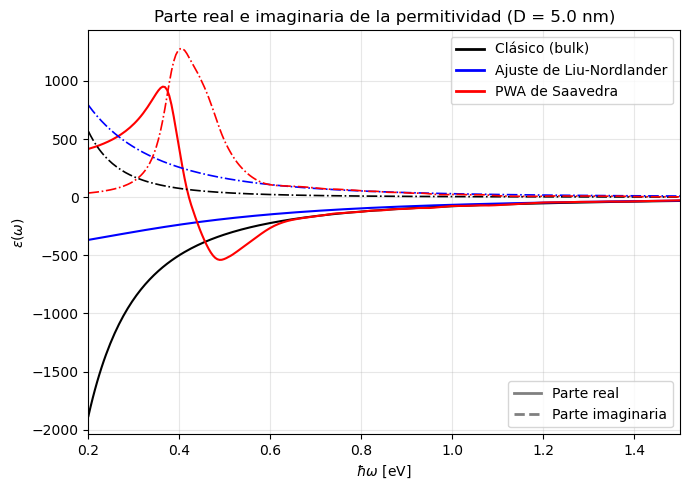

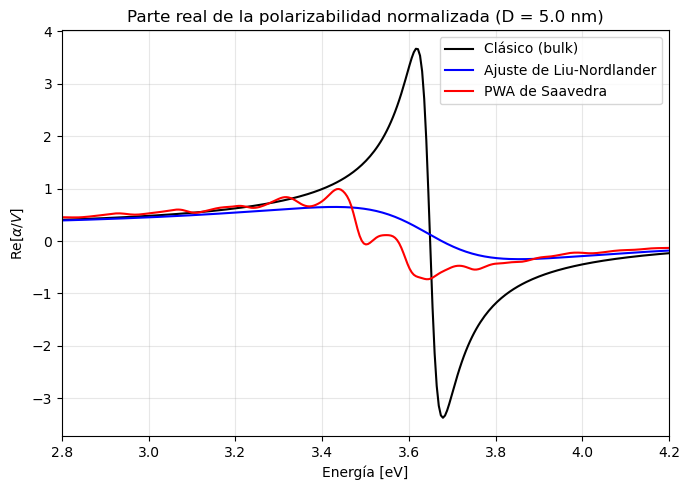

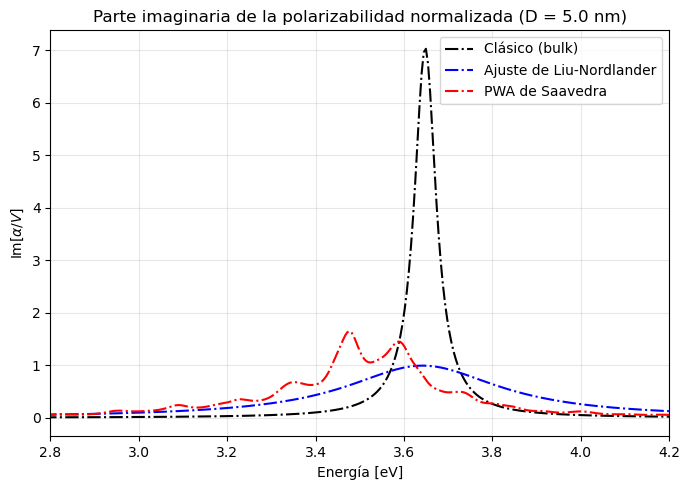

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from plytrons.drude_model import eps_drude_nano_nordlander, eps_drude_bulk, eps_PWA
from plytrons.drude_model import Sij
import plytrons.quantum_well as qw

a_nm = 2.5        # radio de la nanopartícula en nm
D_nm = 2.0 * a_nm # diámetro
EF   = 5.53       # nivel de Fermi en eV

omega_eV = np.linspace(0.2, 5, 1000)

E_matrix = qw.get_bound_states(a_nm)
A_matrix = qw.get_normalization(a_nm, E_matrix)
e_states = qw.e_state_assembly(E_matrix, A_matrix)

def alpha_over_V(eps, eps_h=1.0):
    # α/V normalizada con V = 4πa^3/3
    V = (4*np.pi*a_nm**3/3)
    return a_nm**3 * (eps - eps_h) / (eps + 2.0 * eps_h) / V

def classic_alpha(eps, eps_h = 1.0):
    V = (4*np.pi*a_nm**3/3)
    return  (eps - eps_h) / (eps + 2.0 * eps_h) * 3/4*np.pi 


# Parámetros Drude
eps_h = 1.0
wp = 9.07
eps_b = 4.18
gamma_eV = 0.06

wij, Sij_vals, Ne = Sij(a_nm, EF, e_states)

eps_bulk = eps_drude_bulk(omega_eV, wp_eV=wp, eps_b=eps_b, gamma0=gamma_eV)
eps_nano = eps_drude_nano_nordlander(omega_eV, 2*a_nm, wp_eV=wp, eps_b=eps_b, gamma0=gamma_eV)
eps_pwa  = eps_PWA(wij, Sij_vals, omega_eV, wp_eV=wp, eps_b=eps_b,
                   gamma_eV=gamma_eV, show_progress=True)

# ==========================
# Gráfico ε(ω): Re (línea sólida) e Im (línea punteada)
# ==========================
fig, ax = plt.subplots(figsize=(7, 5))

# Curvas (sin etiquetas repetidas, las leyendas las hacemos con proxies)
ax.plot(omega_eV, np.real(eps_bulk),      'k' ,  linewidth=1.5)
ax.plot(omega_eV, np.real(eps_nano),      'b' ,  linewidth=1.5)
ax.plot(omega_eV, np.real(eps_pwa),       'r' ,  linewidth=1.5)
ax.plot(omega_eV, np.imag(eps_bulk),     'k-.', linewidth=1.2)
ax.plot(omega_eV, np.imag(eps_nano),     'b-.', linewidth=1.2)
ax.plot(omega_eV, np.imag(eps_pwa),      'r-.', linewidth=1.2)

ax.set_xlim(0.2, 1.5)
ax.set_xlabel(r'$\hbar\omega$ [eV]')
ax.set_ylabel(r'$\varepsilon(\omega)$')
ax.set_title(f'Parte real e imaginaria de la permitividad (D = {D_nm:.1f} nm)')
ax.grid(True, alpha=0.3)

# Leyenda 1: colores → modelo
color_handles = [
    Line2D([0], [0], color='k',  lw=2),
    Line2D([0], [0], color='b',  lw=2),
    Line2D([0], [0], color='r',  lw=2),
]
color_labels = ['Clásico (bulk)', 'Ajuste de Liu-Nordlander', 'PWA de Saavedra']
leg1 = ax.legend(color_handles, color_labels, loc='upper right')

# Leyenda 2: estilo de línea → parte real / imaginaria
style_handles = [
    Line2D([0], [0], color='gray', lw=2, linestyle='-'),
    Line2D([0], [0], color='gray', lw=2, linestyle='--'),
]
style_labels = ['Parte real', 'Parte imaginaria']
leg2 = ax.legend(style_handles, style_labels, loc='lower right')

# Asegurar que ambas leyendas se muestren
ax.add_artist(leg1)

fig.tight_layout()

# ==========================
# Polarizabilidades normalizadas
# ==========================
alpha_bulk = alpha_over_V(eps_bulk, eps_h)
alpha_nano = alpha_over_V(eps_nano, eps_h)
alpha_PWA  = alpha_over_V(eps_pwa,  eps_h)

# -------- Re[α/V] ----------
plt.figure(figsize=(7,5))
plt.plot(omega_eV, np.real(alpha_bulk), 'k',  label='Clásico (bulk)')
plt.plot(omega_eV, np.real(alpha_nano), 'b',  label='Ajuste de Liu-Nordlander')
plt.plot(omega_eV, np.real(alpha_PWA),  'r',  label='PWA de Saavedra')

plt.xlabel('Energía [eV]')
plt.ylabel(r'$\mathrm{Re}[\alpha/V]$')
plt.title(f'Parte real de la polarizabilidad normalizada (D = {D_nm:.1f} nm)')
plt.grid(True, alpha=0.3)
plt.xlim(2.8,4.2)
plt.legend()
plt.tight_layout()

# -------- Im[α/V] ----------
plt.figure(figsize=(7,5))
plt.plot(omega_eV, np.imag(alpha_bulk), 'k-.',  label='Clásico (bulk)')
plt.plot(omega_eV, np.imag(alpha_nano), 'b-.',  label='Ajuste de Liu-Nordlander')
plt.plot(omega_eV, np.imag(alpha_PWA),  'r-.',  label='PWA de Saavedra')
plt.xlabel('Energía [eV]')
plt.ylabel(r'$\mathrm{Im}[\alpha/V]$')
plt.title(f'Parte imaginaria de la polarizabilidad normalizada (D = {D_nm:.1f} nm)')
plt.grid(True, alpha=0.3)
plt.xlim(2.8,4.2)
plt.legend()
plt.tight_layout()

plt.show()

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from tqdm.auto import tqdm

from plytrons.drude_model import eps_drude_nano_nordlander, eps_drude_bulk, eps_PWA, Sij
import plytrons.quantum_well as qw

# ============================================================
# Parámetros generales
# ============================================================
EF       = 5.53                 # nivel de Fermi en eV
omega_eV = np.linspace(1, 5, 300)  # malla de energía (ℏω en eV)

eps_h  = 1.0
wp     = 9.07      # eV
eps_b  = 4.18
gammaE = 0.06      # eV

# Radios (en nm) para el barrido
a_nm_list = np.linspace(1, 15, 15)  # ajusta a gusto

# Carpeta para frames temporales
frames_dir = "gif_frames_drude"
os.makedirs(frames_dir, exist_ok=True)

# ============================================================
# Helpers
# ============================================================

def alpha_over_V(eps, a_nm, eps_h=1.0):
    """Polarizabilidad normalizada α/V para una esfera de radio a_nm."""
    return a_nm**3 * (eps - eps_h) / (eps + 2.0 * eps_h)

def compute_for_radius(a_nm, omega_eV, EF, wp_eV, eps_b, gamma_eV, eps_h=1.0):
    """
    Calcula ε_bulk, ε_nano, ε_PWA y α/V para un radio dado.
    """
    # Estados de pozo cuántico
    E_matrix = qw.get_bound_states(a_nm)
    A_matrix = qw.get_normalization(a_nm, E_matrix)
    e_states = qw.e_state_assembly(E_matrix, A_matrix)

    # S_ij del modelo PWA (García de Abajo)
    wij, Sij_vals, Ne = Sij(a_nm, EF, e_states)  # ya lo usabas así

    # Permitividades
    eps_bulk = eps_drude_bulk(omega_eV,
                              wp_eV=wp_eV,
                              eps_b=eps_b,
                              gamma0=gamma_eV)

    eps_nano = eps_drude_nano_nordlander(omega_eV,
                                         2.0 * a_nm,
                                         wp_eV=wp_eV,
                                         eps_b=eps_b,
                                         gamma0=gamma_eV)  # D ≈ 2a

    eps_pwa = eps_PWA(wij, Sij_vals, omega_eV,
                      wp_eV=wp_eV,
                      eps_b=eps_b,
                      gamma_eV=gamma_eV,
                      show_progress=False)

    # Polarizabilidades normalizadas
    alpha_bulk = alpha_over_V(eps_bulk, a_nm, eps_h)
    alpha_nano = alpha_over_V(eps_nano, a_nm, eps_h)
    alpha_pwa  = alpha_over_V(eps_pwa,  a_nm, eps_h)

    return eps_bulk, eps_nano, eps_pwa, alpha_bulk, alpha_nano, alpha_pwa


# ============================================================
# Bucle sobre radios → generar frames
# ============================================================

perm_frames  = []  # para ε
alpha_frames = []  # para α/V

for a_nm in tqdm(a_nm_list, desc="Generando frames para distintos radios"):
    # --- Física ---
    eps_bulk, eps_nano, eps_pwa, alpha_bulk, alpha_nano, alpha_pwa = compute_for_radius(
        a_nm, omega_eV, EF, wp, eps_b, gammaE, eps_h
    )

    # -------------------------
    # 1) Figura de permitividad
    # -------------------------
    fig1, axes1 = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    axR, axI = axes1

    # Re[ε]
    axR.plot(omega_eV, np.real(eps_bulk),       'k--',  label='Re[ε_bulk]')
    axR.plot(omega_eV, np.real(eps_nano),       'C1-.', label='Re[ε_Nordlander]')
    axR.plot(omega_eV, np.real(eps_pwa),        'C2-',  label='Re[ε_PWA]')
    axR.set_xlabel(r'$\hbar\omega$ [eV]')
    axR.set_ylabel(r'$\mathrm{Re}[\varepsilon(\omega)]$')
    axR.grid(True, alpha=0.3)
    axR.legend(fontsize=8)

    # Im[ε]
    axI.plot(omega_eV, np.imag(eps_bulk),       'k--',  label='Im[ε_bulk]')
    axI.plot(omega_eV, np.imag(eps_nano),       'C1-.', label='Im[ε_Nordlander]')
    axI.plot(omega_eV, np.imag(eps_pwa),        'C2-',  label='Im[ε_PWA]')
    axI.set_xlabel(r'$\hbar\omega$ [eV]')
    axI.set_ylabel(r'$\mathrm{Im}[\varepsilon(\omega)]$')
    axI.grid(True, alpha=0.3)
    axI.legend(fontsize=8)

    fig1.suptitle(f'Permitividad efectiva, radio a = {a_nm:.2f} nm')
    fig1.tight_layout(rect=[0, 0, 1, 0.95])

    frame_path1 = os.path.join(frames_dir, f"eps_R_{a_nm:.2f}.png")
    fig1.savefig(frame_path1, dpi=150)
    plt.close(fig1)

    perm_frames.append(imageio.imread(frame_path1))

    # -----------------------------
    # 2) Figura de polarizabilidad
    # -----------------------------
    fig2, axes2 = plt.subplots(1, 2, figsize=(10, 4), sharex=True)
    axR2, axI2 = axes2

    # Re[α/V]
    axR2.plot(omega_eV, np.real(alpha_bulk), 'k',    label='Clásico (bulk)')
    axR2.plot(omega_eV, np.real(alpha_nano), 'C1--', label='Nordlander nano')
    axR2.plot(omega_eV, np.real(alpha_pwa),  'C2-',  label='PWA')
    axR2.set_xlabel('Energía [eV]')
    axR2.set_ylabel(r'$\mathrm{Re}[\alpha/V]$')
    axR2.grid(True, alpha=0.3)
    axR2.legend(fontsize=8)

    # Im[α/V]
    axI2.plot(omega_eV, np.imag(alpha_bulk), 'k',    label='Clásico (bulk)')
    axI2.plot(omega_eV, np.imag(alpha_nano), 'C1--', label='Nordlander nano')
    axI2.plot(omega_eV, np.imag(alpha_pwa),  'C2-',  label='PWA')
    axI2.set_xlabel('Energía [eV]')
    axI2.set_ylabel(r'$\mathrm{Im}[\alpha/V]$')
    axI2.grid(True, alpha=0.3)
    axI2.legend(fontsize=8)

    fig2.suptitle(f'Polarizabilidad normalizada, radio a = {a_nm:.2f} nm')
    fig2.tight_layout(rect=[0, 0, 1, 0.95])

    frame_path2 = os.path.join(frames_dir, f"alpha_R_{a_nm:.2f}.png")
    fig2.savefig(frame_path2, dpi=150)
    plt.close(fig2)

    alpha_frames.append(imageio.imread(frame_path2))

# ============================================================
# Guardar GIFs
# ============================================================

imageio.mimsave("eps_vs_R.gif",   perm_frames,  duration=500)  # s por frame
imageio.mimsave("alpha_vs_R.gif", alpha_frames, duration=500)

print("GIFs guardados como 'eps_vs_R.gif' y 'alpha_vs_R.gif'")



Generando frames para distintos radios:   0%|          | 0/15 [00:00<?, ?it/s]

GIFs guardados como 'eps_vs_R.gif' y 'alpha_vs_R.gif'


In [26]:
imageio.mimsave("eps_vs_R.gif",   perm_frames[1:],  duration=500)  # s por frame
imageio.mimsave("alpha_vs_R.gif", alpha_frames[1:], duration=500)

print("GIFs guardados como 'eps_vs_R.gif' y 'alpha_vs_R.gif'")

GIFs guardados como 'eps_vs_R.gif' y 'alpha_vs_R.gif'


Barrido en radios:   0%|          | 0/9 [00:00<?, ?it/s]

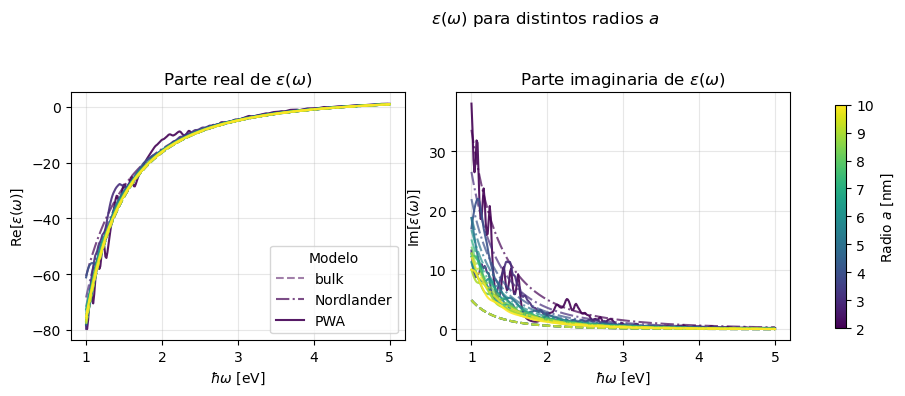

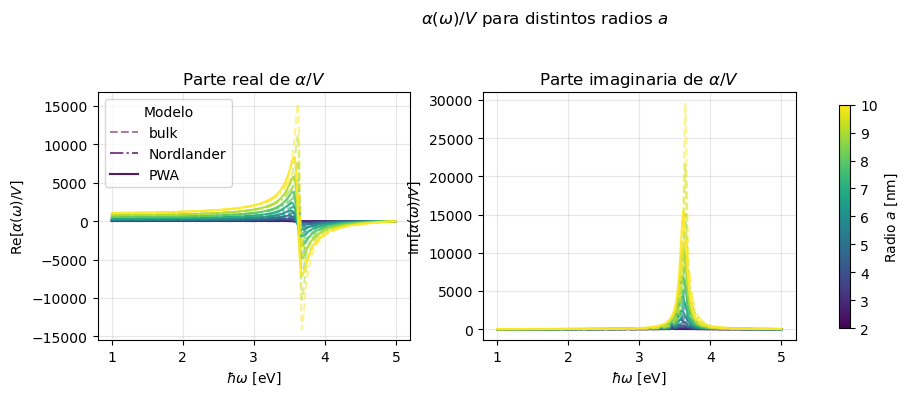

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from tqdm.auto import tqdm

from plytrons.drude_model import (
    eps_drude_nano_nordlander,
    eps_drude_bulk,
    eps_PWA,
    Sij,
)
import plytrons.quantum_well as qw


# ==========================================
# 1) Helper: α/V (misma convención que usabas)
# ==========================================
def alpha_over_V(eps, a_nm, eps_h=1.0):
    """
    Polarizabilidad (≈ a^3 * (eps - eps_h)/(eps + 2 eps_h)).
    La llamamos α/V “normalizada” como en tu código previo.
    """
    return a_nm**3 * (eps - eps_h) / (eps + 2.0 * eps_h)


# ==========================================
# 2) Helper: compute_for_radius
# ==========================================
def compute_for_radius(
    a_nm: float,
    EF: float,
    omega_eV: np.ndarray,
    eps_h: float = 1.0,
    wp_eV: float = 9.07,
    eps_b: float = 4.18,
    gamma_eV: float = 0.06,
):
    """
    Calcula:
      - eps_bulk(ω), eps_Nordlander(ω), eps_PWA(ω)
      - α_bulk/V, α_Nordlander/V, α_PWA/V
    para un radio a_nm dado.
    """
    # 1) Estados de pozo cuántico esférico
    E_matrix = qw.get_bound_states(a_nm)
    A_matrix = qw.get_normalization(a_nm, E_matrix)
    e_states = qw.e_state_assembly(E_matrix, A_matrix)

    # 2) Coeficientes S_ij (PWA)
    wij, Sij_vals, Ne = Sij(a_nm, EF, e_states)

    # 3) Permitividades
    eps_bulk = eps_drude_bulk(
        omega_eV,
        wp_eV=wp_eV,
        eps_b=eps_b,
        gamma0=gamma_eV
    )
    eps_nano = eps_drude_nano_nordlander(
        omega_eV,
        2 * a_nm,          # D ≈ 2a
        wp_eV=wp_eV,
        eps_b=eps_b,
        gamma0=gamma_eV
    )
    eps_pwa = eps_PWA(
        wij,
        Sij_vals,
        omega_eV,
        wp_eV=wp_eV,
        eps_b=eps_b,
        gamma_eV=gamma_eV,
        show_progress=False,
    )

    # 4) Polarizabilidades “normalizadas” α/V
    alpha_bulk = alpha_over_V(eps_bulk, a_nm, eps_h)
    alpha_nano = alpha_over_V(eps_nano, a_nm, eps_h)
    alpha_pwa  = alpha_over_V(eps_pwa,  a_nm, eps_h)

    return {
        "eps_bulk": eps_bulk,
        "eps_nano": eps_nano,
        "eps_pwa":  eps_pwa,
        "alpha_bulk": alpha_bulk,
        "alpha_nano": alpha_nano,
        "alpha_pwa":  alpha_pwa,
    }


# ==========================================
# 3) Barrido en radios
# ==========================================
EF       = 5.53
omega_eV = np.linspace(1.0, 5.0, 300)   # rango espectral [eV]

eps_h  = 1.0
wp     = 9.07
eps_b  = 4.18
gammaE = 0.06

# Radios que quieres explorar (nm)
a_list = np.linspace(2, 10.0, 9)   # cámbialo como quieras

results = []  # lista de dicts

for a_nm in tqdm(a_list, desc="Barrido en radios"):
    res = compute_for_radius(
        a_nm,
        EF,
        omega_eV,
        eps_h=eps_h,
        wp_eV=wp,
        eps_b=eps_b,
        gamma_eV=gammaE,
    )
    results.append(res)


# ==========================================
# 4) Plots estáticos con colormap en radio
# ==========================================
cmap = plt.cm.viridis
norm = mpl.colors.Normalize(vmin=float(np.min(a_list)),
                            vmax=float(np.max(a_list)))
sm   = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

# --------- (A) ε(ω): parte real e imaginaria ---------
fig, (axR, axI) = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

for idx, (a_nm, res) in enumerate(zip(a_list, results)):
    color = cmap(norm(float(a_nm)))

    # Sólo etiquetamos la primera vez para que la leyenda no se llene
    lbl_bulk  = r'bulk'        if idx == 0 else None
    lbl_nano  = r'Nordlander'  if idx == 0 else None
    lbl_pwa   = r'PWA'         if idx == 0 else None

    # Re[ε]
    axR.plot(omega_eV, np.real(res["eps_bulk"]), '--', color=color, alpha=0.5, label=lbl_bulk)
    axR.plot(omega_eV, np.real(res["eps_nano"]), '-.', color=color, alpha=0.7, label=lbl_nano)
    axR.plot(omega_eV, np.real(res["eps_pwa"]),   '-',  color=color, alpha=0.9, label=lbl_pwa)

    # Im[ε]
    axI.plot(omega_eV, np.imag(res["eps_bulk"]), '--', color=color, alpha=0.5)
    axI.plot(omega_eV, np.imag(res["eps_nano"]), '-.', color=color, alpha=0.7)
    axI.plot(omega_eV, np.imag(res["eps_pwa"]),   '-',  color=color, alpha=0.9)

axR.set_xlabel(r'$\hbar\omega$ [eV]')
axR.set_ylabel(r'$\mathrm{Re}[\varepsilon(\omega)]$')
axR.set_title(r'Parte real de $\varepsilon(\omega)$')
axR.grid(True, alpha=0.3)
axR.legend(title="Modelo")

axI.set_xlabel(r'$\hbar\omega$ [eV]')
axI.set_ylabel(r'$\mathrm{Im}[\varepsilon(\omega)]$')
axI.set_title(r'Parte imaginaria de $\varepsilon(\omega)$')
axI.grid(True, alpha=0.3)

fig.suptitle(r'$\varepsilon(\omega)$ para distintos radios $a$')
fig.tight_layout(rect=[0, 0, 0.9, 0.95])

cbar = fig.colorbar(sm, ax=[axR, axI], shrink=0.9)
cbar.set_label('Radio $a$ [nm]')

plt.show()


# --------- (B) α/V: parte real e imaginaria ---------
fig2, (axR2, axI2) = plt.subplots(1, 2, figsize=(11, 4), sharex=True)

for idx, (a_nm, res) in enumerate(zip(a_list, results)):
    color = cmap(norm(float(a_nm)))

    lbl_bulk  = r'bulk'        if idx == 0 else None
    lbl_nano  = r'Nordlander'  if idx == 0 else None
    lbl_pwa   = r'PWA'         if idx == 0 else None

    # Re[α/V]
    axR2.plot(omega_eV, np.real(res["alpha_bulk"]), '--', color=color, alpha=0.5, label=lbl_bulk)
    axR2.plot(omega_eV, np.real(res["alpha_nano"]), '-.', color=color, alpha=0.7, label=lbl_nano)
    axR2.plot(omega_eV, np.real(res["alpha_pwa"]),   '-',  color=color, alpha=0.9, label=lbl_pwa)

    # Im[α/V]
    axI2.plot(omega_eV, np.imag(res["alpha_bulk"]), '--', color=color, alpha=0.5)
    axI2.plot(omega_eV, np.imag(res["alpha_nano"]), '-.', color=color, alpha=0.7)
    axI2.plot(omega_eV, np.imag(res["alpha_pwa"]),   '-',  color=color, alpha=0.9)

axR2.set_xlabel(r'$\hbar\omega$ [eV]')
axR2.set_ylabel(r'$\mathrm{Re}[\alpha(\omega)/V]$')
axR2.set_title(r'Parte real de $\alpha/V$')
axR2.grid(True, alpha=0.3)
axR2.legend(title="Modelo")

axI2.set_xlabel(r'$\hbar\omega$ [eV]')
axI2.set_ylabel(r'$\mathrm{Im}[\alpha(\omega)/V]$')
axI2.set_title(r'Parte imaginaria de $\alpha/V$')
axI2.grid(True, alpha=0.3)

fig2.suptitle(r'$\alpha(\omega)/V$ para distintos radios $a$')
fig2.tight_layout(rect=[0, 0, 0.9, 0.95])

cbar2 = fig2.colorbar(sm, ax=[axR2, axI2], shrink=0.9)
cbar2.set_label('Radio $a$ [nm]')

plt.show()


Barriendo diámetros:   0%|          | 0/5 [00:00<?, ?it/s]

/home/pablo/plytrons/plytrons/drude_model.py:225: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Mfi = _transition_along_z(sf, si, a_nm, state_lf, state_li)
/home/pablo/plytrons/plytrons/drude_model.py:225: NumbaWarning: Cannot cache compiled function "_transition_along_z" as it uses dynamic globals (such as ctypes pointers and large global arrays)
  Mfi = _transition_along_z(sf, si, a_nm, state_lf, state_li)
/home/pablo/plytrons/plytrons/drude_model.py:206: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  state_lf = e_state[lf]
/home/pablo/plytrons/plytrons/drude_model.py:225: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'A', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
  Mfi = _transition_along_z(sf, si, a_nm, state_lf, state_li)
/home/pablo/plytrons/plytrons/drude_mode

AttributeError: 'list' object has no attribute 'lmax'

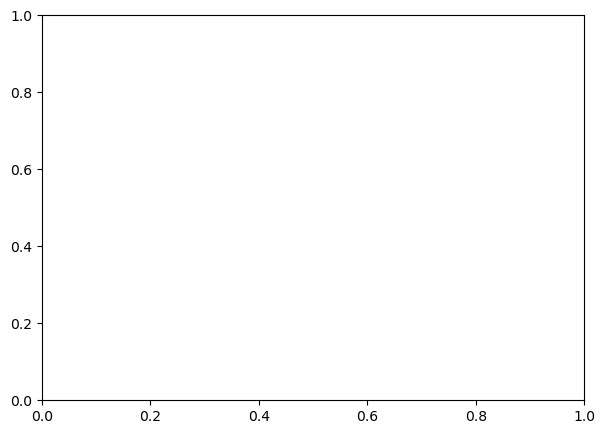

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.constants import hbar, eV, speed_of_light, physical_constants

import plytrons.bcm_sphere as bcm
import plytrons.quantum_well as qw
from plytrons.bcm_sphere import EField, BCMObject
from plytrons.drude_model import Sij, eps_drude_nano_nordlander, eps_PWA

# ==========================
# Constantes globales
# ==========================
c0 = speed_of_light
Z0_SI, *_ = physical_constants["characteristic impedance of vacuum"]
Z0 = Z0_SI * eV    # igual que en tu script original

EF     = 5.53      # eV
wp     = 9.07 * eV / hbar   # rad/s (tal como lo tenías)
eps_b  = 4.18
gamma0 = 0.060     # eV
eps_h  = 1.0
vf     = 1.39e6    # m/s
lmax   = 10

# malla en frecuencia (rad/s) y en energía (eV)
w = np.linspace(2.8, 4, 200) * eV / hbar  # rad/s
E_eV = w * hbar / eV                        # eje x en eV

# Campo incidente, igual al original
efield = EField(
    E0=1.0,
    k_hat=bcm.v_normalize([1, 0, 0]),
    e_hat=bcm.v_normalize([0, 1, 0]),
)

# ==========================
# Qabs para UNA esfera de diámetro D_nm
# ==========================
def Qabs_single_sphere(D_nm: float) -> np.ndarray:
    """
    Reproduce tu pipeline original para una sola esfera de diámetro D_nm
    y devuelve Qabs(E) de ESA esfera, con la misma normalización.
    """
    a_nm = D_nm / 2.0

    # --- Drude params dependientes de D (como en tu código) ---
    gw = (gamma0 + (hbar/eV)*vf/a_nm) * eV / hbar  # rad/s (no lo usamos directo en eps_PWA,
                                                   # pero lo dejamos si luego quieres volver al Drude simple)

    # --- Estados de pozo y S_ij (para PWA) ---
    E_matrix = qw.get_bound_states(a_nm)
    A_matrix = qw.get_normalization(a_nm, E_matrix)
    e_states = qw.e_state_assembly(E_matrix, A_matrix)

    wij, Sij_vals, Ne = Sij(a_nm, EF, e_states)

    # --- eps(ω) EXACTAMENTE como en tu script BCM original ---
    def eps_drude_local(x):
        # x viene en rad/s (ω)
        if D_nm >= 30.0:
            # Nordlander nano: mismo llamado que tenías
            return eps_drude_nano_nordlander(
                2*np.pi*c0/x*1e6,       # λ(μm)
                wp_eV=wp,
                eps_b=eps_b,
                gamma_eV=gamma0*eV/hbar
            )
        else:
            # PWA con tus Sij
            return eps_PWA(
                wij, Sij_vals,
                2*np.pi*c0/x*1e6,       # λ(μm) → tu implementación lo acepta así
                wp_eV=wp,
                eps_b=eps_b,
                gamma_eV=gamma0*eV/hbar,
                show_progress=False
            )
        
    delta_ = 1.0  # separación entre esferas en nm (para evitar solapamiento)

    # --- Objeto BCM (una sola esfera en el origen) ---
    obj1 = BCMObject(
        label=f"Sphere1_D{D_nm:.1f}nm",
        diameter=D_nm,
        lmax=lmax,
        eps=eps_drude_local,
        position=np.array([0.0, (D_nm + delta_)/2, 0.0])
    )

    obj2 = BCMObject(
        label=f"Sphere2_D{D_nm:.1f}nm",
        diameter=D_nm,
        lmax=lmax,
        eps=eps_drude_local,
        position=np.array([0.0, -(D_nm + delta_)/2, 0.0])
    )

    obj = [obj1, obj2]  # lista de objetos (aquí dos esferas)

    Np = 1
    Gi = [bcm.Ginternal(obj)]
    G0 = [[bcm.Gexternal(obj, obj)]]
    Sv = [bcm.Efield_coupling(obj, efield)]

    # --- Resolver BCM en toda la malla w ---
    dx_max = lmax * (lmax + 1) + (lmax + 1) - 1
    coef = np.zeros((dx_max, w.size), dtype=complex)

    for iw, wi in enumerate(w):
        c, Si = bcm.solve_BCM(wi, eps_h, [obj], efield, Gi, G0, Sv)
        coef[:, iw] = c[0]

    # Coeficientes internos para campos/EM_power
    lam_um = 2*np.pi*3e14 / w
    obj.set_coefficients(lam_um, coef)

    # --- Potencias EM ---
    Psca, Pabs = bcm.EM_power(w, eps_h, Gi, G0, [obj])
    Pabs_arr = np.array(Pabs)   # shape (1, Nw)
    Pabs_sphere = Pabs_arr[0]   # la única esfera

    # --- Misma normalización que tu gráfico original ---
    I0 = efield.E0**2 / (2 * Z0)
    R  = D_nm / 2.0
    A  = np.pi * R**2
    Qabs = Pabs_sphere / (I0 * A)

    return Qabs


# ==========================
# Sweep en diámetros con colormap
# ==========================
D_list = np.array([5.0, 7.5, 10.0, 15.0, 20.0])   # pon aquí los diámetros que quieras

cmap = plt.cm.plasma
norm = plt.Normalize(vmin=D_list.min(), vmax=D_list.max())

fig, ax = plt.subplots(figsize=(7, 5))

for D in tqdm(D_list, desc="Barriendo diámetros"):
    Qabs_D = Qabs_single_sphere(D)
    color = cmap(norm(D))
    ax.plot(E_eV, Qabs_D, color=color, label=f"D = {D:.1f} nm")

# Colorbar para el diámetro
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("Diámetro D [nm]")

ax.set_xlabel("Photon energy (eV)")
ax.set_ylabel(r"Absorption efficiency $Q_{\mathrm{abs}}$")
ax.set_title("Evolución de la absorción de una esfera aislada con el diámetro")
ax.grid(True, ls=":")
fig.tight_layout()
plt.show()

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.constants import hbar, eV, speed_of_light, physical_constants

import plytrons.bcm_sphere as bcm
import plytrons.quantum_well as qw
from plytrons.bcm_sphere import EField, BCMObject
from plytrons.drude_model import Sij, eps_drude_nano_nordlander, eps_PWA

# ==========================
# Constantes globales
# ==========================
c0 = speed_of_light
Z0_SI, *_ = physical_constants["characteristic impedance of vacuum"]
Z0 = Z0_SI * eV    # igual que en tu script original

EF     = 5.53      # eV
wp     = 9.07 * eV / hbar   # rad/s (tal como lo tenías)
eps_b  = 4.18
gamma0 = 0.060     # eV
eps_h  = 1.0
vf     = 1.39e6    # m/s
lmax   = 10

D_FIXED = 10.0     # Diámetro fijo (nm)

# malla en frecuencia (rad/s) y en energía (eV)
w = np.linspace(2.8, 4, 200) * eV / hbar  # rad/s
E_eV = w * hbar / eV                      # eje x en eV

# ==========================
# Preparar objeto BCM una sola vez (independiente de polarización)
# ==========================
a_nm = D_FIXED / 2.0

# --- Drude params dependientes de D (como en tu código) ---
gw = (gamma0 + (hbar / eV) * vf / a_nm) * eV / hbar  # lo dejo por si lo quieres usar luego

# --- Estados de pozo y S_ij (para PWA) ---
E_matrix = qw.get_bound_states(a_nm)
A_matrix = qw.get_normalization(a_nm, E_matrix)
e_states = qw.e_state_assembly(E_matrix, A_matrix)

wij, Sij_vals, Ne = Sij(a_nm, EF, e_states)

# --- eps(ω) EXACTAMENTE como en tu script BCM original ---
def eps_drude_local(x):
    # x viene en rad/s (ω)
    if D_FIXED >= 30.0:
        # Nordlander nano
        return eps_drude_nano_nordlander(
            2 * np.pi * c0 / x * 1e6,    # λ(μm)
            wp_eV=wp,
            eps_b=eps_b,
            gamma_eV=gamma0 * eV / hbar
        )
    else:
        # PWA con tus Sij
        return eps_PWA(
            wij, Sij_vals,
            2 * np.pi * c0 / x * 1e6,    # λ(μm)
            wp_eV=wp,
            eps_b=eps_b,
            gamma_eV=gamma0 * eV / hbar,
            show_progress=False
        )

# --- Objeto BCM (una sola esfera en el origen) ---
# obj = [BCMObject(
#     label=f"Sphere_D{D_FIXED:.1f}nm",
#     diameter=D_FIXED,
#     lmax=lmax,
#     eps=eps_drude_local,
#     position=np.array([0.0, 0.0, 0.0])
# )]

delta_ = 1

obj = [

    BCMObject(
        label='Sphere1',
        diameter=D_FIXED,
        lmax=lmax,
        eps=eps_drude_local,
        position=np.array([0, (D_FIXED + delta_)/2, 0])
    ),
    BCMObject(
        label='Sphere2',
        diameter=D_FIXED,
        lmax=lmax,
        eps=eps_drude_local,
        position=np.array([0, -(D_FIXED + delta_)/2, 0])
    ) 
]   


# Estas cosas no dependen de la polarización
Gi = [bcm.Ginternal(obj)]
G0 = [[bcm.Gexternal(obj, obj)]]

dx_max = lmax * (lmax + 1) + (lmax + 1) - 1

# ==========================
# Qabs para UNA esfera con polarización dada
# ==========================
def Qabs_single_sphere_for_polarization(e_hat_vec: np.ndarray) -> np.ndarray:
    """
    Calcula Q_abs(E) para la esfera de diámetro fijo D_FIXED,
    con una polarización especificada por e_hat_vec.
    """
    # Campo incidente para esta polarización
    # k_hat lo mantenemos fijo en x
    efield = EField(
        E0=1.0,
        k_hat=bcm.v_normalize([1, 0, 0]),
        e_hat=bcm.v_normalize(e_hat_vec),
    )

    # Acople de campo para esta polarización
    Sv = [bcm.Efield_coupling(obj, efield)]

    coef = np.zeros((dx_max, w.size), dtype=complex)

    for iw, wi in enumerate(w):
        c, Si = bcm.solve_BCM(wi, eps_h, [obj], efield, Gi, G0, Sv)
        coef[:, iw] = c[0]

    # Coeficientes internos para campos/EM_power
    lam_um = 2 * np.pi * 3e14 / w
    obj.set_coefficients(lam_um, coef)

    # Potencias EM
    Psca, Pabs = bcm.EM_power(w, eps_h, Gi, G0, [obj])
    Pabs_arr = np.array(Pabs)   # shape (1, Nw)
    Pabs_sphere = Pabs_arr[0]   # la única esfera

    # Misma normalización que tu gráfico original
    I0 = efield.E0**2 / (2 * Z0)
    R  = D_FIXED / 2.0
    A  = np.pi * R**2
    Qabs = Pabs_sphere / (I0 * A)

    return Qabs


# ==========================
# Sweep en ángulo de polarización con colormap
# ==========================
# θ = 0° → E // y ; θ = 90° → E // z
theta_deg_list = np.linspace(0.0, 90.0, 6)   # ajusta el número de ángulos que quieras

cmap = plt.cm.plasma
norm = plt.Normalize(vmin=theta_deg_list.min(), vmax=theta_deg_list.max())

fig, ax = plt.subplots(figsize=(7, 5))

for theta_deg in tqdm(theta_deg_list, desc="Barriendo polarización"):
    theta = np.deg2rad(theta_deg)
    # Vector de polarización en el plano yz
    e_hat_vec = np.array([0.0, np.cos(theta), np.sin(theta)])

    Qabs_theta = Qabs_single_sphere_for_polarization(e_hat_vec)
    color = cmap(norm(theta_deg))
    ax.plot(E_eV, Qabs_theta, color=color, label=f"θ = {theta_deg:.1f}°")

# Colorbar para el ángulo de polarización
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"Ángulo de polarización $\theta$ (°)  [E en plano $yz$]")

ax.set_xlabel("Photon energy (eV)")
ax.set_ylabel(r"Absorption efficiency $Q_{\mathrm{abs}}$")
ax.set_title(f"Absorción de una esfera aislada D = {D_FIXED:.1f} nm vs ángulo de polarización")
ax.grid(True, ls=":")
fig.tight_layout()
plt.show()


AttributeError: 'list' object has no attribute 'lmax'

Barriendo polarización dímero:   0%|          | 0/6 [00:00<?, ?it/s]

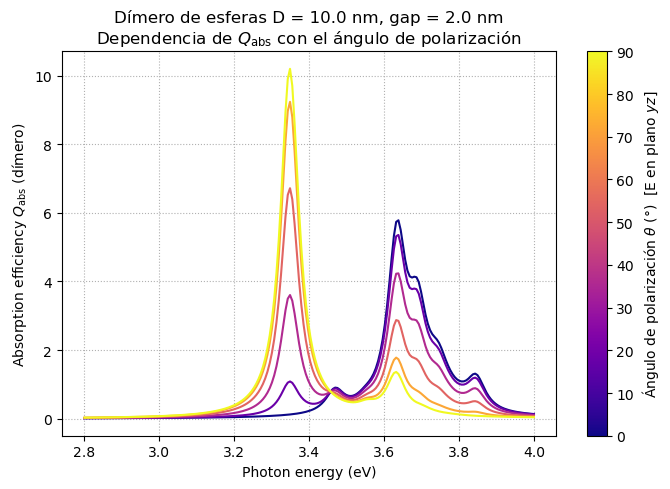

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from scipy.constants import hbar, eV, speed_of_light, physical_constants

import plytrons.bcm_sphere as bcm
import plytrons.quantum_well as qw
from plytrons.bcm_sphere import EField, BCMObject
from plytrons.drude_model import Sij, eps_drude_nano_nordlander, eps_PWA

# ==========================
# Constantes globales
# ==========================
c0 = speed_of_light
Z0_SI, *_ = physical_constants["characteristic impedance of vacuum"]
Z0 = Z0_SI * eV    # igual que en tu script original

EF     = 5.53      # eV
wp     = 9.07 * eV / hbar   # rad/s
eps_b  = 4.18
gamma0 = 0.060     # eV
eps_h  = 1.0
vf     = 1.39e6    # m/s
lmax   = 10

D_FIXED = 10.0     # Diámetro fijo (nm)
R_nm    = D_FIXED / 2.0

# Gap entre las esferas (nm)
gap_nm  = 2.0
center_distance_nm = D_FIXED + gap_nm

# malla en frecuencia (rad/s) y en energía (eV)
w = np.linspace(2.8, 4, 200) * eV / hbar  # rad/s
E_eV = w * hbar / eV                      # eje x en eV

# ==========================
# Preparar pozo cuántico y eps(ω) para este D_FIXED
# ==========================
a_nm = D_FIXED / 2.0

# Drude params dependientes de D (como en tu código)
gw = (gamma0 + (hbar / eV) * vf / a_nm) * eV / hbar  # lo dejo por si lo usas luego

# Estados de pozo y S_ij (para PWA)
E_matrix = qw.get_bound_states(a_nm)
A_matrix = qw.get_normalization(a_nm, E_matrix)
e_states = qw.e_state_assembly(E_matrix, A_matrix)

wij, Sij_vals, Ne = Sij(a_nm, EF, e_states)

def eps_drude_local(x):
    """
    x: frecuencia angular ω (rad/s)
    """
    if D_FIXED >= 30.0:
        # Nordlander nano
        return eps_drude_nano_nordlander(
            2 * np.pi * c0 / x * 1e6,    # λ(μm)
            wp_eV=wp,
            eps_b=eps_b,
            gamma_eV=gamma0 * eV / hbar
        )
    else:
        # PWA con tus Sij
        return eps_PWA(
            wij, Sij_vals,
            2 * np.pi * c0 / x * 1e6,    # λ(μm)
            wp_eV=wp,
            eps_b=eps_b,
            gamma_eV=gamma0 * eV / hbar,
            show_progress=False
        )

# ==========================
# Objetos BCM: dímero
# Eje del dímero: z
# ==========================
pos1 = np.array([0.0, 0.0, -center_distance_nm / 2.0])
pos2 = np.array([0.0, 0.0,  center_distance_nm / 2.0])
pos3 = np.array([0, 0, -(center_distance_nm/2)*np.sqrt(3)])

obj1 = BCMObject(
    label=f"Sphere1_D{D_FIXED:.1f}nm",
    diameter=D_FIXED,
    lmax=lmax,
    eps=eps_drude_local,
    position=pos1
)

obj2 = BCMObject(
    label=f"Sphere2_D{D_FIXED:.1f}nm",
    diameter=D_FIXED,
    lmax=lmax,
    eps=eps_drude_local,
    position=pos2
)

obj3 = BCMObject(
    label=f"Sphere3_D{D_FIXED:.1f}nm",
    diameter=D_FIXED,
    lmax=lmax,
    eps=eps_drude_local,
    position=pos3
)


objs = [obj1, obj2, obj3]

# Green internos y externos
Gi = [bcm.Ginternal(o) for o in objs]
G0 = [[bcm.Gexternal(oi, oj) for oj in objs] for oi in objs]

# Dimensión de coeficientes (igual que antes)
dx_max = lmax * (lmax + 1) + (lmax + 1) - 1

# contenedores de coeficientes para cada esfera
coef_list = [
    np.zeros((dx_max, w.size), dtype=complex) for _ in objs
]

# ==========================
# Función: Qabs para dímero con una polarización dada
# ==========================
def Qabs_dimer_for_polarization(e_hat_vec: np.ndarray) -> np.ndarray:
    """
    Calcula Q_abs(E) para el dímero de diámetro fijo D_FIXED,
    con una polarización especificada por e_hat_vec (vector de 3 componentes).
    E rotando en el plano yz, k_hat fijo en x.
    """
    # Campo incidente para esta polarización
    efield = EField(
        E0=1.0,
        k_hat=bcm.v_normalize([1, 0, 0]),         # propagación en x
        e_hat=bcm.v_normalize(e_hat_vec),         # polarización en el plano yz
    )

    # Acople de campo para cada esfera
    Sv = [bcm.Efield_coupling(o, efield) for o in objs]

    # limpiar coeficientes
    for arr in coef_list:
        arr[:] = 0.0

    # resolver BCM para cada frecuencia
    for iw, wi in enumerate(w):
        c, Si = bcm.solve_BCM(wi, eps_h, objs, efield, Gi, G0, Sv)
        # c es lista con coeficientes para cada objeto
        for io in range(len(objs)):
            coef_list[io][:, iw] = c[io]

    # set_coefficients para cada esfera
    lam_um = 2 * np.pi * 3e14 / w   # mantengo tu fórmula original
    for io, obj in enumerate(objs):
        obj.set_coefficients(lam_um, coef_list[io])

    # Potencias EM
    Psca, Pabs = bcm.EM_power(w, eps_h, Gi, G0, objs)
    Pabs_arr = np.array(Pabs)   # shape (2, Nw)
    Pabs_total = Pabs_arr.sum(axis=0)

    # Normalización: sección geométrica total ≈ 2 esferas
    I0 = efield.E0**2 / (2 * Z0)
    A_single = np.pi * R_nm**2
    A_total  = 2.0 * A_single
    Qabs = Pabs_total / (I0 * A_total)

    return Qabs


# ==========================
# Sweep en ángulo de polarización con colormap
# ==========================
# θ = 0° → E // y (transversal)
# θ = 90° → E // z (longitudinal, a lo largo del eje del dímero)
theta_deg_list = np.linspace(0.0, 90.0, 6)   # cambia cuantos ángulos quieras

cmap = plt.cm.plasma
norm = plt.Normalize(vmin=theta_deg_list.min(), vmax=theta_deg_list.max())

fig, ax = plt.subplots(figsize=(7, 5))

for theta_deg in tqdm(theta_deg_list, desc="Barriendo polarización dímero"):
    theta = np.deg2rad(theta_deg)
    # vector de polarización en el plano yz
    e_hat_vec = np.array([0.0, np.cos(theta), np.sin(theta)])

    Qabs_theta = Qabs_dimer_for_polarization(e_hat_vec)
    color = cmap(norm(theta_deg))
    ax.plot(E_eV, Qabs_theta, color=color, label=f"θ = {theta_deg:.1f}°")

# Colorbar para el ángulo de polarización
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label(r"Ángulo de polarización $\theta$ (°)  [E en plano $yz$]")

ax.set_xlabel("Photon energy (eV)")
ax.set_ylabel(r"Absorption efficiency $Q_{\mathrm{abs}}$ (dímero)")
ax.set_title(
    f"Dímero de esferas D = {D_FIXED:.1f} nm, gap = {gap_nm:.1f} nm\n"
    r"Dependencia de $Q_{\mathrm{abs}}$ con el ángulo de polarización"
)
ax.grid(True, ls=":")
fig.tight_layout()
plt.show()
